In [1]:
%reload_ext autoreload
%autoreload 2

from comet_ml import Experiment
import h5py
import matplotlib.pyplot as plt
import numpy as np
import argparse


import importlib
import random
import os
from algorithms.server.server import Server
from algorithms.trainmodel.models import *
from utils.plot_utils import *
import torch

#torch.set_default_dtype(torch.float64)


def main(experiment, dataset, algorithm, model, batch_size, learning_rate, alpha, eta, L, rho, num_glob_iters,
         local_epochs, optimizer, numedges, times, commet, gpu):

    device = torch.device("cuda:{}".format(gpu) if torch.cuda.is_available() and gpu != -1 else "cpu")

    for i in range(times):
        print("---------------Running time:------------",i)

        # Generate model
        if(model == "mclr"):
            if(dataset == "human_activity"):
                model = Mclr_CrossEntropy(561,6).to(device), model
                print("Hey")
            else:
                model = Mclr_Logistic().to(device), model

        if(model == "linear_regression"):
            model = Linear_Regression(40,1).to(device), model

        if model == "logistic_regression":
            model = Logistic_Regression(300).to(device), model
        
        if model == "MLP" and dataset == "a9a":
            model = DNN( input_dim = 123, output_dim = 2).to(device), model
        if model == "MLP" and dataset == "human_activity":
            model = DNN( input_dim = 561, mid_dim = 561, output_dim = 6).to(device), model
        if model == "MLP" and dataset == "w8a":
            model = DNN( input_dim = 300, output_dim = 2).to(device), model
        if model == "MLP" and dataset == "Mnist":
            model = DNN().to(device), model
        if model == 'CNN':
            model = Net().to(device), model
        # select algorithm
        if(commet):
            experiment.set_name(dataset + "_" + algorithm + "_" + model[1] + "_" + str(batch_size) + "b_" + str(learning_rate) + "lr_" + str(alpha) + "al_" + str(eta) + "eta_" + str(L) + "L_" + str(rho) + "p_" +  str(num_glob_iters) + "ge_"+ str(local_epochs) + "le_"+ str(numedges) +"u")
        server = Server(experiment, device, dataset, algorithm, model, batch_size, learning_rate, alpha, eta,  L, num_glob_iters, local_epochs, optimizer, numedges, i)
        
        server.train()
        server.test()


In [2]:
sophia_params = {
    "dataset": "Mnist",
    "algorithm": "Sophia",
    "model": "MLP",
    "batch_size": 64,
    "learning_rate": 0.001,
    "alpha": (0.90, 0.95),
    "eta": 1.0 * 20.,
    "L": 0.001,
    "rho": 200,
    "num_glob_iters": 2 * 41,
    "local_epochs": 1,
    "optimizer": "Sophia",
    "numedges": 32,
    "times": 1,
    "commet": False,
    "gpu": 0
}



DONE_params = {
    "dataset": "Mnist",
    "algorithm": "DONE",
    "model": "MLP",
    "batch_size": 0,
    "learning_rate": 1,
    "alpha": 0.003,
    "eta": 1.0,
    "L": 1e-3,
    "rho": 0.01,
    "num_glob_iters": 41,
    "local_epochs": 40,
    "optimizer": "DONE",
    "numedges": 32,
    "times": 1,
    "commet": True,
    "gpu": 0
}

GD_params = {
    "dataset": "Mnist",
    "algorithm": "GD",
    "model": "MLP",
    "batch_size": 64,
    "learning_rate": 0.01,
    "alpha": 0.03,
    "eta": 20.0,
    "L": 1e-3,
    "rho": 0.01,
    "num_glob_iters": 2 * 41,
    "local_epochs": 1,
    "optimizer": "DONE",
    "numedges": 30,
    "times": 1,
    "commet": False,
    "gpu": 0
}

'''
Newton_params = {
    "dataset": "Mnist",
    "algorithm": "Newton",
    "model": "MLP",
    "batch_size": 0,
    "learning_rate": 1,
    "alpha": 0.03,
    "eta": 1.0,
    "L": 1e-3,
    "rho": 0.01,
    "num_glob_iters": 500,
    "local_epochs": 40,
    "optimizer": "Newton",
    "numedges": 30,
    "times": 1,
    "commet": True,
    "gpu": 0
}

'''

'\nNewton_params = {\n    "dataset": "Mnist",\n    "algorithm": "Newton",\n    "model": "MLP",\n    "batch_size": 0,\n    "learning_rate": 1,\n    "alpha": 0.03,\n    "eta": 1.0,\n    "L": 1e-3,\n    "rho": 0.01,\n    "num_glob_iters": 500,\n    "local_epochs": 40,\n    "optimizer": "Newton",\n    "numedges": 30,\n    "times": 1,\n    "commet": True,\n    "gpu": 0\n}\n\n'

In [3]:
experiment = Experiment(
        api_key="q24VqIVkFNEOugLA3T0YFFFvE",
        project_name="sophia",
        workspace="abdulmomen96",
    )
main(experiment, **sophia_params)
experiment.end()    


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/abdulmomen96/sophia/1254f4dba5fc42c5bd1ef902f58823da



---------------Running time:------------ 0
Number of edges / total edges: 32  /  32
Total number of parameters: 79510
-------------Round number:  0  -------------
Win rate = 0.09109545969060495
-------------Round number:  1  -------------
Average Test Accuracy          :  0.11024078909196403
Average Global Trainning Accuracy:  0.1179533839244231
Average Global Trainning Loss    :  2.335980603656884
Win rate = 0.2954219595019494
-------------Round number:  2  -------------
Average Test Accuracy          :  0.31418624891209745
Average Global Trainning Accuracy:  0.3239701099581849
Average Global Trainning Loss    :  2.1749315786162304
Win rate = 0.30132058860520694
-------------Round number:  3  -------------
Average Test Accuracy          :  0.47571801566579636
Average Global Trainning Accuracy:  0.4785891280780548
Average Global Trainning Loss    :  2.023446725694982
Win rate = 0.31095459690604954
-------------Round number:  4  -------------
Average Test Accuracy          :  0.56930664

Win rate = 0.9331907936108665
-------------Round number:  35  -------------
Average Test Accuracy          :  0.8754279083260806
Average Global Trainning Accuracy:  0.875793712250271
Average Global Trainning Loss    :  0.5000196613171751
Win rate = 0.933417180228902
-------------Round number:  36  -------------
Average Test Accuracy          :  0.8771105308964317
Average Global Trainning Accuracy:  0.8773811367508131
Average Global Trainning Loss    :  0.49348408824725104
Win rate = 0.9350647717268268
-------------Round number:  37  -------------
Average Test Accuracy          :  0.8786190890629533
Average Global Trainning Accuracy:  0.879045996592845
Average Global Trainning Loss    :  0.4872049063153361
Win rate = 0.9358822789586215
-------------Round number:  38  -------------
Average Test Accuracy          :  0.8794313896141572
Average Global Trainning Accuracy:  0.8800720148675856
Average Global Trainning Loss    :  0.4817578896328597
Win rate = 0.9358319708212803
-------------Rou

Average Test Accuracy          :  0.8982883666956774
Average Global Trainning Accuracy:  0.8996244385937742
Average Global Trainning Loss    :  0.38906014820398405
Win rate = 0.9416048295811847
-------------Round number:  70  -------------
Average Test Accuracy          :  0.8990426457789382
Average Global Trainning Accuracy:  0.8998954622889886
Average Global Trainning Loss    :  0.3873837562432244
Win rate = 0.9418941013708968
-------------Round number:  71  -------------
Average Test Accuracy          :  0.8996228604583696
Average Global Trainning Accuracy:  0.9002439213256931
Average Global Trainning Loss    :  0.3857556857504453
Win rate = 0.9421959501949441
-------------Round number:  72  -------------
Average Test Accuracy          :  0.8999129677980853
Average Global Trainning Accuracy:  0.9004762273501626
Average Global Trainning Loss    :  0.3841772978937587
Win rate = 0.9421959501949441
-------------Round number:  73  -------------
Average Test Accuracy          :  0.9001450

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/abdulmomen96/sophia/1254f4dba5fc42c5bd1ef902f58823da
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     glob_acc [81]   : (0.11024078909196403, 0.901885697708152)
COMET INFO:     loss [317]      : (0.1968664824962616, 2.3384246826171875)
COMET INFO:     train_acc [81]  : (0.1179533839244231, 0.9033413349852872)
COMET INFO:     train_loss [81] : (0.3714672772161027, 2.335980603656884)
COMET INFO:   Uploads:
COMET INFO:     conda-environment-definition : 1
COMET INFO:     conda-info                   : 1
COMET INFO:     conda-specification          : 1
COMET INFO:     environment details          : 1
COMET INFO:     filenam

In [4]:
'''
Human Activity
Sophia
-------------Round number:  40  -------------
Average Test Accuracy          :  0.8502321981424149
Average Global Trainning Accuracy:  0.8495139338950097
Average Global Trainning Loss    :  1.0823885845349968
Clipping rate = 0.576000928907216

"learning_rate": 0.0001,
    "alpha": (0.9, 0.95),
    "eta": 1.0 * 50,
    "L": 0.001,
    "rho": 20,


GD
-------------Round number:  40  -------------
Average Global Accuracy          :  0.20936532507739938
Average Global Trainning Accuracy:  0.20764744005184704
Average Global Trainning Loss    :  1.7220779072828905


'''

'''
MNIST MLP
Sophia 
-------------Round number:  39  -------------
Average Global Accuracy          :  0.8934867045115028
Average Global Trainning Accuracy:  0.8913894080996885
Average Global Trainning Loss    :  0.3557637022975078

GD
-------------Round number:  40  -------------
Average Global Accuracy          :  0.5679713175978488
Average Global Trainning Accuracy:  0.5671775700934579
Average Global Trainning Loss    :  1.9333872663551401

'''

'\nMNIST MLP\nSophia \n-------------Round number:  39  -------------\nAverage Global Accuracy          :  0.8934867045115028\nAverage Global Trainning Accuracy:  0.8913894080996885\nAverage Global Trainning Loss    :  0.3557637022975078\n\nGD\n-------------Round number:  40  -------------\nAverage Global Accuracy          :  0.5679713175978488\nAverage Global Trainning Accuracy:  0.5671775700934579\nAverage Global Trainning Loss    :  1.9333872663551401\n\n'

In [5]:
from utils.plot_utils import get_training_data_value, simple_read_data

In [6]:


rs_train_acc_sop, rs_train_loss_sop, rs_glob_acc_sop = simple_read_data("Mnist_Sophia_0.01_(0.9, 0.95)_20.0_0.1_32u_64b_1_0_25db")
rs_train_acc_done, rs_train_loss_done, rs_glob_acc_done = simple_read_data("Mnist_DONE_1_0.003_1.0_0.001_32u_0b_40_0")
#("Mnist_DONE_1_0.008_1.0_0.001_32u_0b_40_0")
rs_train_acc_gd, rs_train_loss_gd, rs_glob_acc_gd = simple_read_data("Mnist_GD_0.01_0.03_20.0_0.001_30u_64b_1_0")

Mnist_Sophia_0.01_(0.9, 0.95)_20.0_0.1_32u_64b_1_0_25db
Mnist_DONE_1_0.003_1.0_0.001_32u_0b_40_0
Mnist_GD_0.01_0.03_20.0_0.001_30u_64b_1_0


In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots
plt.figure(figsize=(10, 5))
x = np.arange(0, 82)
x_DONE = np.arange(0, 2 * 41, 2)
xlim = 41
print(rs_glob_acc_sop[:80].shape)
# Subplot 1: Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(x[:80], rs_glob_acc_sop[:80], label='FedSophia-25dB', linestyle='--', marker='o', markevery=4)
#plt.plot(x_DONE, rs_glob_acc_done, label='DONE', linestyle='--', marker='s', markevery=4)
#plt.plot(x, rs_glob_acc_gd, label='FedAVG', linestyle='--', marker='D', markevery=4)

plt.title('Test Accuracy')
plt.xlabel('Communication Rounds')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Training Loss
plt.subplot(1, 2, 2)
plt.plot(x[:80], rs_train_loss_sop[:80], label='FedSophia-25dB', linestyle='--', marker='o', markevery=4)
#plt.plot(x_DONE, rs_train_loss_done, label='DONE', linestyle='--', marker='s', markevery=4)
#plt.plot(x, rs_train_loss_gd, label='FedAVG', linestyle='--', marker='D', markevery=4)

plt.title('Training Loss')
plt.xlabel('Communication Rounds')
plt.ylabel('Loss')
plt.legend()

plt.savefig('Mnist_MLP_.eps', format='eps')

plt.tight_layout()
plt.show()


(80,)


In [ ]:


rs_train_acc_sop, rs_train_loss_sop, rs_glob_acc_sop = simple_read_data("Fashion_Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.1_20u_64b_1_0")
#rs_train_acc_done, rs_train_loss_done, rs_glob_acc_done = simple_read_data("Mnist_DONE_1_0.003_1.0_0.001_32u_0b_40_0")
#("Mnist_DONE_1_0.008_1.0_0.001_32u_0b_40_0")
rs_train_acc_gd, rs_train_loss_gd, rs_glob_acc_gd = simple_read_data("Fashion_Mnist_GD_0.01_0.03_20.0_0.001_20u_64b_1_0")


# Create a figure with two subplots
plt.figure(figsize=(10, 5))
x = np.arange(0, 82)
x_DONE = np.arange(0, 2 * 41, 2)
xlim = 41
print(rs_glob_acc_sop[:80].shape)
# Subplot 1: Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(x[:80], rs_glob_acc_sop[:80], label='FedSophia', linestyle='--', marker='o', markevery=4)
#plt.plot(x_DONE, rs_glob_acc_done, label='DONE', linestyle='--', marker='s', markevery=4)
plt.plot(x, rs_glob_acc_gd, label='FedAVG', linestyle='--', marker='D', markevery=4)

plt.title('Test Accuracy')
plt.xlabel('Communication Rounds')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Training Loss
plt.subplot(1, 2, 2)
plt.plot(x[:80], rs_train_loss_sop[:80], label='FedSophia', linestyle='--', marker='o', markevery=4)
#plt.plot(x_DONE, rs_train_loss_done, label='DONE', linestyle='--', marker='s', markevery=4)
plt.plot(x, rs_train_loss_gd, label='FedAVG', linestyle='--', marker='D', markevery=4)

plt.title('Training Loss')
plt.xlabel('Communication Rounds')
plt.ylabel('Loss')
plt.legend()

plt.savefig('Mnist_MLP_.eps', format='eps')

plt.tight_layout()
plt.show()


In [ ]:


rs_train_acc_sop, rs_train_loss_sop, rs_glob_acc_sop = simple_read_data("Mnist_Sophia_0.005_(0.9, 0.95)_20.0_0.1_32u_64b_1_0_CNN_IID")
#rs_train_acc_done, rs_train_loss_done, rs_glob_acc_done = simple_read_data("Mnist_DONE_1_0.003_1.0_0.001_32u_0b_40_0")
#("Mnist_DONE_1_0.008_1.0_0.001_32u_0b_40_0")
rs_train_acc_gd, rs_train_loss_gd, rs_glob_acc_gd = simple_read_data("Mnist_GD_0.01_0.03_20.0_0.001_30u_64b_1_0_CNN_IID")

b = rs_train_loss_gd

# Create a figure with two subplots
plt.figure(figsize=(10, 5))
x = np.arange(0, 82)
x_DONE = np.arange(0, 2 * 41, 2)
xlim = 41
print(rs_glob_acc_sop[:80].shape)
# Subplot 1: Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(x[:80], rs_glob_acc_sop[:80], label='FedSophia', linestyle='--', marker='o', markevery=4)
#plt.plot(x_DONE, rs_glob_acc_done, label='DONE', linestyle='--', marker='s', markevery=4)
plt.plot(x, rs_glob_acc_gd, label='FedAVG', linestyle='--', marker='D', markevery=4)

plt.title('Test Accuracy')
plt.xlabel('Communication Rounds')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Training Loss
plt.subplot(1, 2, 2)
plt.plot(x[:80], rs_train_loss_sop[:80], label='FedSophia', linestyle='--', marker='o', markevery=4)
#plt.plot(x_DONE, rs_train_loss_done, label='DONE', linestyle='--', marker='s', markevery=4)
plt.plot(x, rs_train_loss_gd, label='FedAVG', linestyle='--', marker='D', markevery=4)

plt.title('Training Loss')
plt.xlabel('Communication Rounds')
plt.ylabel('Loss')
plt.legend()

plt.savefig('Mnist_MLP_.eps', format='eps')

plt.tight_layout()
plt.show()


In [ ]:


rs_train_acc_sop, rs_train_loss_sop, rs_glob_acc_sop = simple_read_data("Mnist_Sophia_0.005_(0.9, 0.95)_20.0_0.1_32u_64b_1_0_CNN_NIID")
#rs_train_acc_done, rs_train_loss_done, rs_glob_acc_done = simple_read_data("Mnist_DONE_1_0.003_1.0_0.001_32u_0b_40_0")
#("Mnist_DONE_1_0.008_1.0_0.001_32u_0b_40_0")
rs_train_acc_gd, rs_train_loss_gd, rs_glob_acc_gd = simple_read_data("Mnist_GD_0.01_0.03_20.0_0.001_30u_64b_1_0_CNN_NIID")

a = rs_train_loss_gd

# Create a figure with two subplots
plt.figure(figsize=(10, 5))
x = np.arange(0, 82)
x_DONE = np.arange(0, 2 * 41, 2)
xlim = 41
print(rs_glob_acc_sop[:80].shape)
# Subplot 1: Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(x[:80], rs_glob_acc_sop[:80], label='FedSophia', linestyle='--', marker='o', markevery=4)
#plt.plot(x_DONE, rs_glob_acc_done, label='DONE', linestyle='--', marker='s', markevery=4)
plt.plot(x, rs_glob_acc_gd, label='FedAVG', linestyle='--', marker='D', markevery=4)

plt.title('Test Accuracy')
plt.xlabel('Communication Rounds')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Training Loss
plt.subplot(1, 2, 2)
plt.plot(x[:80], rs_train_loss_sop[:80], label='FedSophia', linestyle='--', marker='o', markevery=4)
#plt.plot(x_DONE, rs_train_loss_done, label='DONE', linestyle='--', marker='s', markevery=4)
plt.plot(x, rs_train_loss_gd, label='FedAVG', linestyle='--', marker='D', markevery=4)

plt.title('Training Loss')
plt.xlabel('Communication Rounds')
plt.ylabel('Loss')
plt.legend()

plt.savefig('Mnist_MLP_.eps', format='eps')

plt.tight_layout()
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_25dB
Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_30dB
Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_35dB


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


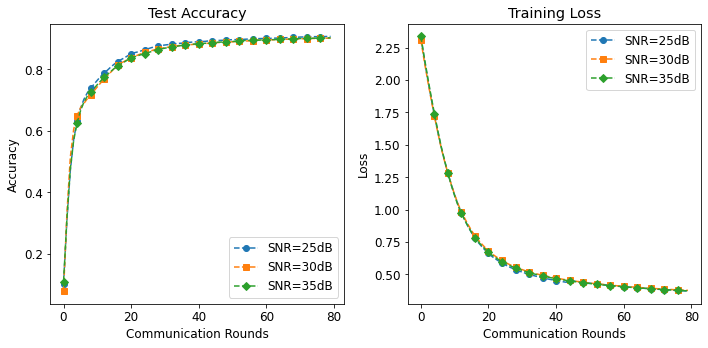

In [2]:

# Sopgia with SNRs

from utils.plot_utils import get_training_data_value, simple_read_data
import matplotlib.pyplot as plt
import numpy as np
rs_train_acc_sop25, rs_train_loss_sop25, rs_glob_acc_sop25 = simple_read_data("Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_25dB")
rs_train_acc_sop30, rs_train_loss_sop30, rs_glob_acc_sop30 = simple_read_data("Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_30dB")
#("Mnist_DONE_1_0.008_1.0_0.001_32u_0b_40_0")
rs_train_acc_sop35, rs_train_loss_sop35, rs_glob_acc_sop35 = simple_read_data("Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_35dB")


# Create a figure with two subplots
plt.figure(figsize=(10, 5))
x = np.arange(0, 82)
x_DONE = np.arange(0, 2 * 41, 2)
xlim = 41

# Subplot 1: Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(x[:80], rs_glob_acc_sop25[:80], label='SNR=25dB', linestyle='--', marker='o', markevery=4)
plt.plot(x[:80], rs_glob_acc_sop30[:80], label='SNR=30dB', linestyle='--', marker='s', markevery=4)
plt.plot(x[:80], rs_glob_acc_sop35[:80], label='SNR=35dB', linestyle='--', marker='D', markevery=4)

plt.title('Test Accuracy')
plt.xlabel('Communication Rounds')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Training Loss
plt.subplot(1, 2, 2)
plt.plot(x[:80], rs_train_loss_sop25[:80], label='SNR=25dB', linestyle='--', marker='o', markevery=4)
plt.plot(x[:80], rs_train_loss_sop30[:80], label='SNR=30dB', linestyle='--', marker='s', markevery=4)
plt.plot(x[:80], rs_train_loss_sop35[:80], label='SNR=35dB', linestyle='--', marker='D', markevery=4)

plt.title('Training Loss')
plt.xlabel('Communication Rounds')
plt.ylabel('Loss')
plt.legend()

plt.savefig('Mnist_MLP_.eps', format='eps')

plt.tight_layout()
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_fix_5dB
Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_fix_25dB
Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_fix_35dB


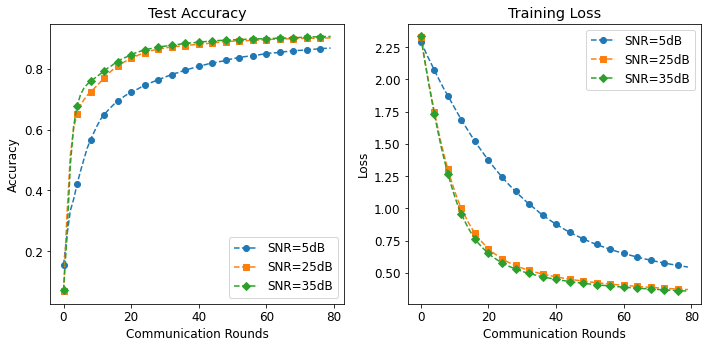

In [3]:

# Sopgia with SNRs

from utils.plot_utils import get_training_data_value, simple_read_data
import matplotlib.pyplot as plt
import numpy as np
rs_train_acc_sop25, rs_train_loss_sop25, rs_glob_acc_sop25 = simple_read_data("Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_fix_5dB")
rs_train_acc_sop30, rs_train_loss_sop30, rs_glob_acc_sop30 = simple_read_data("Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_fix_25dB")
#("Mnist_DONE_1_0.008_1.0_0.001_32u_0b_40_0")
rs_train_acc_sop35, rs_train_loss_sop35, rs_glob_acc_sop35 = simple_read_data("Mnist_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0_fix_35dB")


# Create a figure with two subplots
plt.figure(figsize=(10, 5))
x = np.arange(0, 82)
x_DONE = np.arange(0, 2 * 41, 2)
xlim = 41

# Subplot 1: Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(x[:80], rs_glob_acc_sop25[:80], label='SNR=5dB', linestyle='--', marker='o', markevery=4)
plt.plot(x[:80], rs_glob_acc_sop30[:80], label='SNR=25dB', linestyle='--', marker='s', markevery=4)
plt.plot(x[:80], rs_glob_acc_sop35[:80], label='SNR=35dB', linestyle='--', marker='D', markevery=4)

plt.title('Test Accuracy')
plt.xlabel('Communication Rounds')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Training Loss
plt.subplot(1, 2, 2)
plt.plot(x[:80], rs_train_loss_sop25[:80], label='SNR=5dB', linestyle='--', marker='o', markevery=4)
plt.plot(x[:80], rs_train_loss_sop30[:80], label='SNR=25dB', linestyle='--', marker='s', markevery=4)
plt.plot(x[:80], rs_train_loss_sop35[:80], label='SNR=35dB', linestyle='--', marker='D', markevery=4)

plt.title('Training Loss')
plt.xlabel('Communication Rounds')
plt.ylabel('Loss')
plt.legend()

plt.savefig('Mnist_MLP_.eps', format='eps')

plt.tight_layout()
plt.show()


In [ ]:
a - b

In [ ]:
#1.027

np.mean(np.equal(np.ones((20, 1), np.float32), 0.0))

In [ ]:
model = DNN( input_dim = 123, output_dim = 2)


In [ ]:

        #print(grads[i].sign())
#print(f"Clipping rate = {1 - (winrate / param_count)}")
x = sum(p.numel() for p in model.parameters() if p.requires_grad)
x 

In [ ]:
"""
Mnist MLP settings
sophia_params = {
    "dataset": "Mnist",
    "algorithm": "Sophia",
    "model": "MLP",
    "batch_size": 64,
    "learning_rate": 0.01,
    "alpha": (0.90, 0.95),
    "eta": 1.0 * 20,
    "L": 0.1,
    "rho": 20,
    "num_glob_iters": 2 * 41,
    "local_epochs": 1,
    "optimizer": "Sophia",
    "numedges": 32,
    "times": 1,
    "commet": False,
    "gpu": 0
}



DONE_params = {
    "dataset": "Mnist",
    "algorithm": "DONE",
    "model": "MLP",
    "batch_size": 64,
    "learning_rate": 1,
    "alpha": 0.003,
    "eta": 1.0,
    "L": 1e-3,
    "rho": 0.01,
    "num_glob_iters": 41,
    "local_epochs": 40,
    "optimizer": "DONE",
    "numedges": 32,
    "times": 1,
    "commet": True,
    "gpu": 0
}

GD_params = {
    "dataset": "Mnist",
    "algorithm": "GD",
    "model": "MLP",
    "batch_size": 64,
    "learning_rate": 0.01,
    "alpha": 0.03,
    "eta": 20.0,
    "L": 1e-3,
    "rho": 0.01,
    "num_glob_iters": 2 * 41,
    "local_epochs": 1,
    "optimizer": "DONE",
    "numedges": 30,
    "times": 1,
    "commet": False,
    "gpu": 0
}







"""

In [ ]:
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 2, 1)
        self.conv2 = nn.Conv2d(16, 32, 2, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(18432, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = nn.ReLU()(x)
        x = nn.MaxPool2d(2, 1)(x)
        x = self.dropout1(x)
        x = self.conv2(x)
        x = nn.ReLU()(x)
        x = nn.MaxPool2d(2, 1)(x)
        x = self.dropout2(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = self.fc2(x)
        output = x#F.log_softmax(x, dim=1)
        return output
    


In [ ]:
model = Net()

In [ ]:
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total number of parameters: {param_count}")

In [ ]:
class CNN28(nn.Module):
    def __init__(self):
        super(CNN28, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # Adjusted input size based on the dimensions after pooling
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

# Create an instance of the model
model = CNN28()

In [ ]:
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total number of parameters: {param_count}")